In [39]:
import os
import json
import pandas as pd
import numpy as np
from pathlib import Path

# -----------------------------------------------------------
# SELECIONE AS PASTAS DE RESULTADO DESEJADAS (result_XXXX)
# Deixe a lista vazia [] para carregar TODAS as pastas encontradas.
# Exemplo: RESULT_DIRS = ['result_0005', 'result_0006']
# -----------------------------------------------------------
RESULT_DIRS = [
    'result_0007',
    'result_0009',
    'result_0015'
] 
# -----------------------------------------------------------

NOTEBOOK_DIR = Path(os.getcwd())
PROJECT_ROOT = NOTEBOOK_DIR.parent
RESULTS_BASE = PROJECT_ROOT / 'project' / 'results'
BEST_OBJ_CSV = PROJECT_ROOT / 'best_solutions' / 'best_objectives.csv'

# --- Carrega melhores objetivos ---
df_best = pd.read_csv(BEST_OBJ_CSV)
df_best['instance'] = df_best['instance'].str.replace('.txt', '', regex=False)

# --- Carrega resultados ---
def carregar_resultados(results_base):
    registros = []
    if RESULT_DIRS:
        result_dirs = sorted([Path(results_base) / d for d in RESULT_DIRS])
    else:
        result_dirs = sorted(Path(results_base).glob('result_*'))
    if not result_dirs:
        print('[AVISO] Nenhuma pasta result_XXXX encontrada em:', results_base)
        return pd.DataFrame()
    for result_dir in result_dirs:
        dataset_dirs = sorted([d for d in result_dir.iterdir() if d.is_dir() and d.name != 'temp'])
        for dataset_dir in dataset_dirs:
            dataset = dataset_dir.name
            csv_files = sorted(dataset_dir.glob('*.csv'))
            for csv_file in csv_files:
                instance_stem = csv_file.stem
                try:
                    df_inst = pd.read_csv(csv_file)
                    df_inst['dataset']    = dataset
                    df_inst['instance']   = instance_stem
                    df_inst['result_dir'] = result_dir.name
                    registros.append(df_inst)
                except Exception as e:
                    print('[ERRO] Falha ao ler', csv_file, ':', e)
    if not registros:
        print('[AVISO] Nenhum CSV de instancia encontrado.')
        return pd.DataFrame()
    return pd.concat(registros, ignore_index=True)

df_raw = carregar_resultados(RESULTS_BASE)
print('Total de linhas carregadas:', len(df_raw))

# --- Filtra feasible ---
if df_raw.empty:
    df_ok = pd.DataFrame()
else:
    df_ok = df_raw[df_raw['status'] == 'feasible'].copy()
    print('Execucoes com status feasible:', len(df_ok), 'de', len(df_raw))
    df_ok['objective'] = pd.to_numeric(df_ok['objective'], errors='coerce')
    df_ok['exec_time'] = pd.to_numeric(df_ok['exec_time'], errors='coerce')

# --- Calcula % do melhor objetivo ---
if not df_ok.empty:
    df_ok = df_ok.merge(
        df_best[['dataset', 'instance', 'best_objective']],
        on=['dataset', 'instance'],
        how='left'
    )
    n_sem_best = df_ok['best_objective'].isna().sum()
    if n_sem_best > 0:
        print(f'[AVISO] {n_sem_best} linhas sem melhor objetivo conhecido.')
    df_ok['pct_best'] = (
        df_ok['objective'] / df_ok['best_objective'] * 100
    )
    print('% do melhor objetivo calculado com sucesso.')

# --- Tabela por Dataset + Algoritmo ---
def formata(media, dp, casas=4):
    fmt = '{:.' + str(casas) + 'f}'
    return fmt.format(media) + ' +- ' + fmt.format(dp)

if df_ok.empty or 'pct_best' not in df_ok.columns:
    print('[INFO] Nenhum dado disponivel para gerar a tabela.')
else:
    df_valido = df_ok.dropna(subset=['pct_best', 'exec_time'])
    grupos = df_valido.groupby(['dataset', 'algo_id'])
    tabela = grupos.agg(
        pct_media   = ('pct_best',  'mean'),
        pct_dp      = ('pct_best',  'std'),
        tempo_media = ('exec_time', 'mean'),
        tempo_dp    = ('exec_time', 'std'),
        n_runs      = ('run_id',    'count'),
    ).reset_index()
    tabela['pct_dp']   = tabela['pct_dp'].fillna(0.0)
    tabela['tempo_dp'] = tabela['tempo_dp'].fillna(0.0)
    tabela = tabela.sort_values('pct_media', ascending=False)
    tabela['% Melhor + DP'] = tabela.apply(lambda r: formata(r['pct_media'],   r['pct_dp']),   axis=1)
    tabela['Tempo media + DP']   = tabela.apply(lambda r: formata(r['tempo_media'], r['tempo_dp']), axis=1)
    tabela_exibir = tabela[['dataset', 'algo_id', 'n_runs', '% Melhor + DP', 'Tempo media + DP']].rename(columns={
        'dataset':  'Dataset',
        'algo_id':  'Algoritmo',
        'n_runs':   'Total Runs',
    })

    display(tabela_exibir.reset_index(drop=True))

# --- Exporta CSV ---
OUTPUT_DIR = PROJECT_ROOT / 'notebooks' / 'output'
OUTPUT_DIR.mkdir(exist_ok=True)

if not df_ok.empty and 'pct_best' in df_ok.columns:
    path = OUTPUT_DIR / 'tabela_por_dataset.csv'
    tabela_exibir.to_csv(path, index=False)
    print('Tabela salva em:', path)
else:
    print('[INFO] Nada exportado - nenhum dado disponivel.')

Total de linhas carregadas: 366
Execucoes com status feasible: 348 de 366
% do melhor objetivo calculado com sucesso.


,Dataset,Algoritmo,Total Runs,% Melhor + DP,Tempo media + DP
0,b,sa_default,23,98.3239 +- 1.8922,601.1249 +- 15.6471
1,x,sa_default,19,98.1873 +- 1.8746,604.1408 +- 5.2227
2,x,aisle_first,75,98.0213 +- 2.2609,0.8213 +- 0.4797
3,b,aisle_first,75,97.8403 +- 2.3864,0.7019 +- 0.4513
4,a,sa_default,40,97.5750 +- 4.6595,352.5264 +- 287.1718
5,a,aisle_first,100,93.8507 +- 10.1796,0.3369 +- 0.2700
6,a,sa_new,16,83.8402 +- 8.4800,280.2246 +- 276.1583


Tabela salva em: /home/vinicius/Documents/CEFET/TCC/pfc2/notebooks/output/tabela_por_dataset.csv


In [40]:
# --- Pareto frontier (% do melhor vs exec_time) ---
def pareto_frontier(df, x_col, y_col, minimize_x=True, minimize_y=True):
    pareto = []
    for i in range(len(df)):
        dominated = False
        for j in range(len(df)):
            if i == j:
                continue
            xi, yi = df.iloc[i][x_col], df.iloc[i][y_col]
            xj, yj = df.iloc[j][x_col], df.iloc[j][y_col]
            better_x = (xj < xi) if minimize_x else (xj > xi)
            better_y = (yj < yi) if minimize_y else (yj > yi)
            if better_x and better_y:
                dominated = True
                break
            if (xj == xi and better_y) or (yj == yi and better_x):
                dominated = True
                break
        pareto.append(not dominated)
    return pareto

if 'tabela' in locals() and not tabela.empty:
    tabela['pareto'] = False
    for dataset in tabela['dataset'].unique():
        mask = tabela['dataset'] == dataset
        idx = tabela[mask].index
        pareto_mask = pareto_frontier(tabela.loc[idx], 'pct_media', 'tempo_media', minimize_x=False)
        tabela.loc[idx, 'pareto'] = pareto_mask

    n_front = tabela['pareto'].sum()
    print(f'Total de algoritmos na fronteira de Pareto: {n_front} de {len(tabela)}')
    print()

    cols_exibir = ['dataset', 'algo_id', 'pct_media', 'tempo_media', 'pareto']
    df_pareto = tabela[cols_exibir].sort_values(['dataset', 'pareto', 'pct_media'],
                                                 ascending=[True, False, False])
    display(df_pareto.reset_index(drop=True))

    # --- Salva CSV ---
    path = OUTPUT_DIR / 'pareto_frontier.csv'
    df_pareto.to_csv(path, index=False)
    print('Pareto frontier salva em:', path)
else:
    print('[INFO] Variavel `tabela` nao disponivel. Execute a celula anterior primeiro.')

Total de algoritmos na fronteira de Pareto: 6 de 7



,dataset,algo_id,pct_media,tempo_media,pareto
0,a,sa_default,97.574966,352.526425,True
1,a,aisle_first,93.850686,0.336920,True
2,a,sa_new,83.840211,280.224625,False
3,b,sa_default,98.323883,601.124913,True
4,b,aisle_first,97.840258,0.701920,True
5,x,sa_default,98.187340,604.140842,True
6,x,aisle_first,98.021303,0.821280,True


Pareto frontier salva em: /home/vinicius/Documents/CEFET/TCC/pfc2/notebooks/output/pareto_frontier.csv


Grafico salvo em: /home/vinicius/Documents/CEFET/TCC/pfc2/notebooks/output/pareto_frontier.png


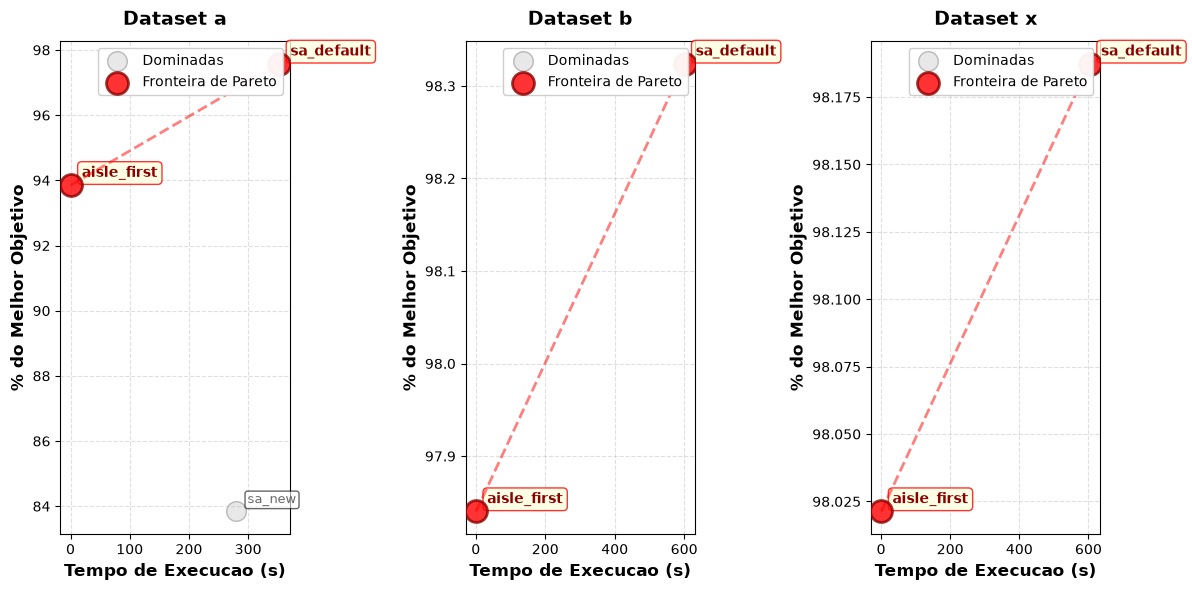

In [41]:
# --- Scatter plot: Pareto frontier por dataset ---
import matplotlib.pyplot as plt

if 'tabela' in locals() and not tabela.empty and 'pareto' in tabela.columns:
    datasets = sorted(tabela['dataset'].unique())
    n_ds = len(datasets)
    fig, axes = plt.subplots(1, n_ds, figsize=(12, 6), squeeze=False)

    for ax, ds in zip(axes[0], datasets):
        sub = tabela[tabela['dataset'] == ds].copy()
        pareto = sub[sub['pareto']]
        dominated = sub[~sub['pareto']]

        ax.scatter(dominated['tempo_media'], dominated['pct_media'],
                   s=200, alpha=0.5, c='lightgray', edgecolors='gray', linewidth=1, label='Dominadas')
        ax.scatter(pareto['tempo_media'], pareto['pct_media'],
                   s=250, alpha=0.8, c='red', edgecolors='darkred', linewidth=2,
                   label='Fronteira de Pareto', zorder=5)

        pareto_sorted = pareto.sort_values('tempo_media')
        ax.plot(pareto_sorted['tempo_media'], pareto_sorted['pct_media'],
                'r--', alpha=0.5, linewidth=2, zorder=4)

        def add_label(row):
            label = row['algo_id']
            if row['pareto']:
                ax.annotate(label, (row['tempo_media'], row['pct_media']),
                            textcoords='offset points', xytext=(8, 6), ha='left',
                            fontsize=10, fontweight='bold', color='darkred',
                            bbox=dict(boxstyle='round,pad=0.3', facecolor='lightyellow',
                                      alpha=0.8, edgecolor='red'))
            else:
                ax.annotate(label, (row['tempo_media'], row['pct_media']),
                            textcoords='offset points', xytext=(8, 6), ha='left',
                            fontsize=9, color='dimgray',
                            bbox=dict(boxstyle='round,pad=0.2', facecolor='white', alpha=0.6))

        sub.apply(add_label, axis=1)

        ax.set_xlabel('Tempo de Execucao (s)', fontsize=12, fontweight='bold')
        ax.set_ylabel('% do Melhor Objetivo', fontsize=12, fontweight='bold')
        ax.set_title(f'Dataset {ds}', fontsize=14, fontweight='bold', pad=12)
        ax.legend(loc='upper right', fontsize=10, framealpha=0.95)
        ax.grid(True, linestyle='--', alpha=0.4)

    plt.tight_layout()
    path_png = OUTPUT_DIR / 'pareto_frontier.png'
    fig.savefig(path_png, dpi=150, bbox_inches='tight')
    print('Grafico salvo em:', path_png)
    plt.show()
else:
    print('[INFO] Execute a celula anterior (Pareto frontier) primeiro.')

Grafico salvo em: /home/vinicius/Documents/CEFET/TCC/pfc2/notebooks/output/barplot_dataset_a.png


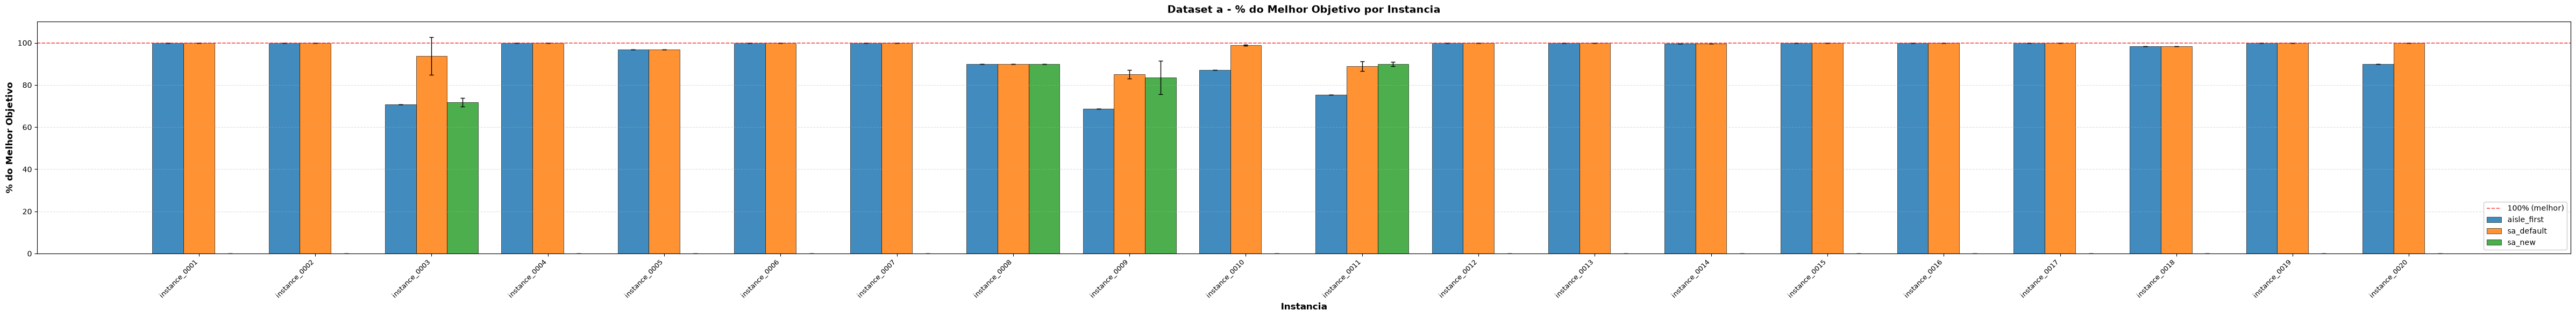

Grafico salvo em: /home/vinicius/Documents/CEFET/TCC/pfc2/notebooks/output/barplot_dataset_b.png


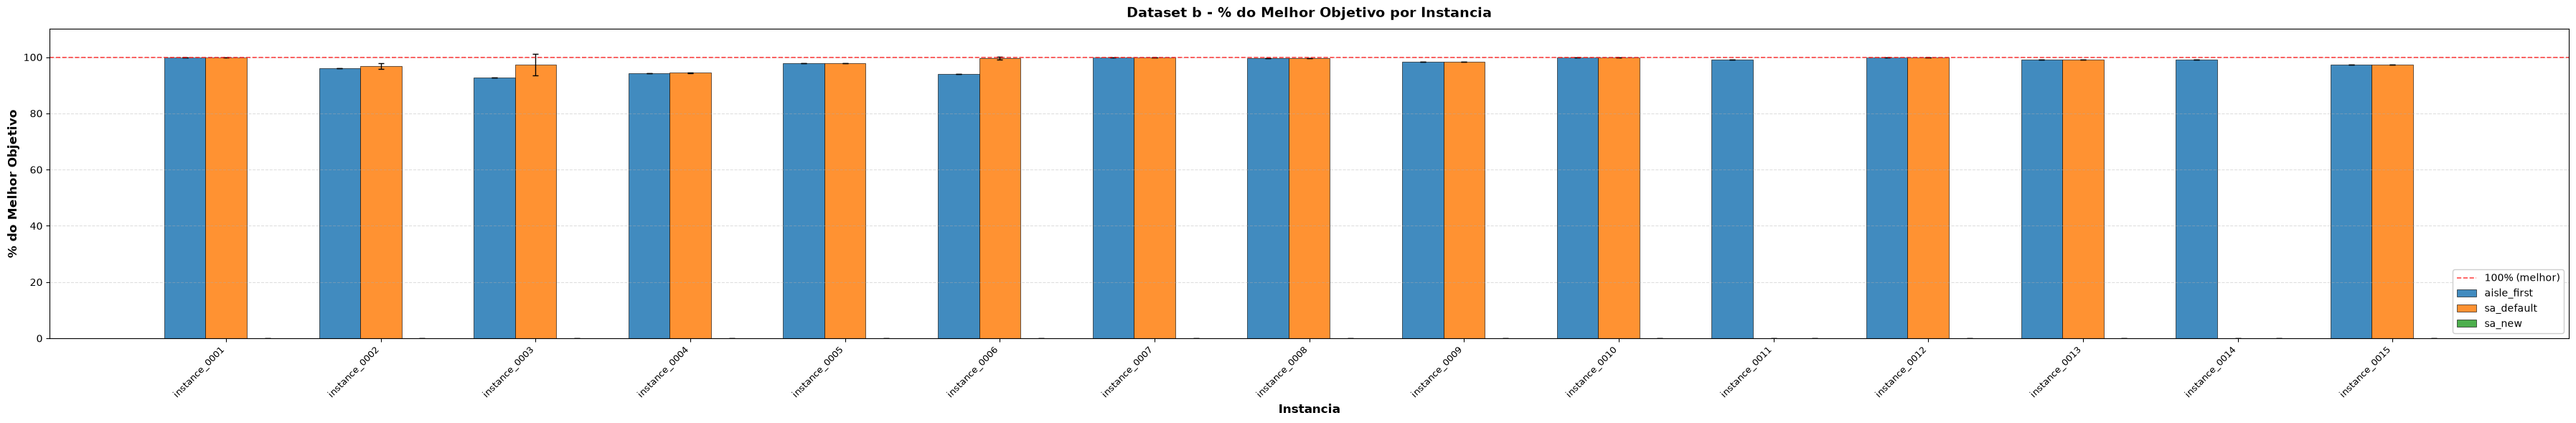

Grafico salvo em: /home/vinicius/Documents/CEFET/TCC/pfc2/notebooks/output/barplot_dataset_x.png


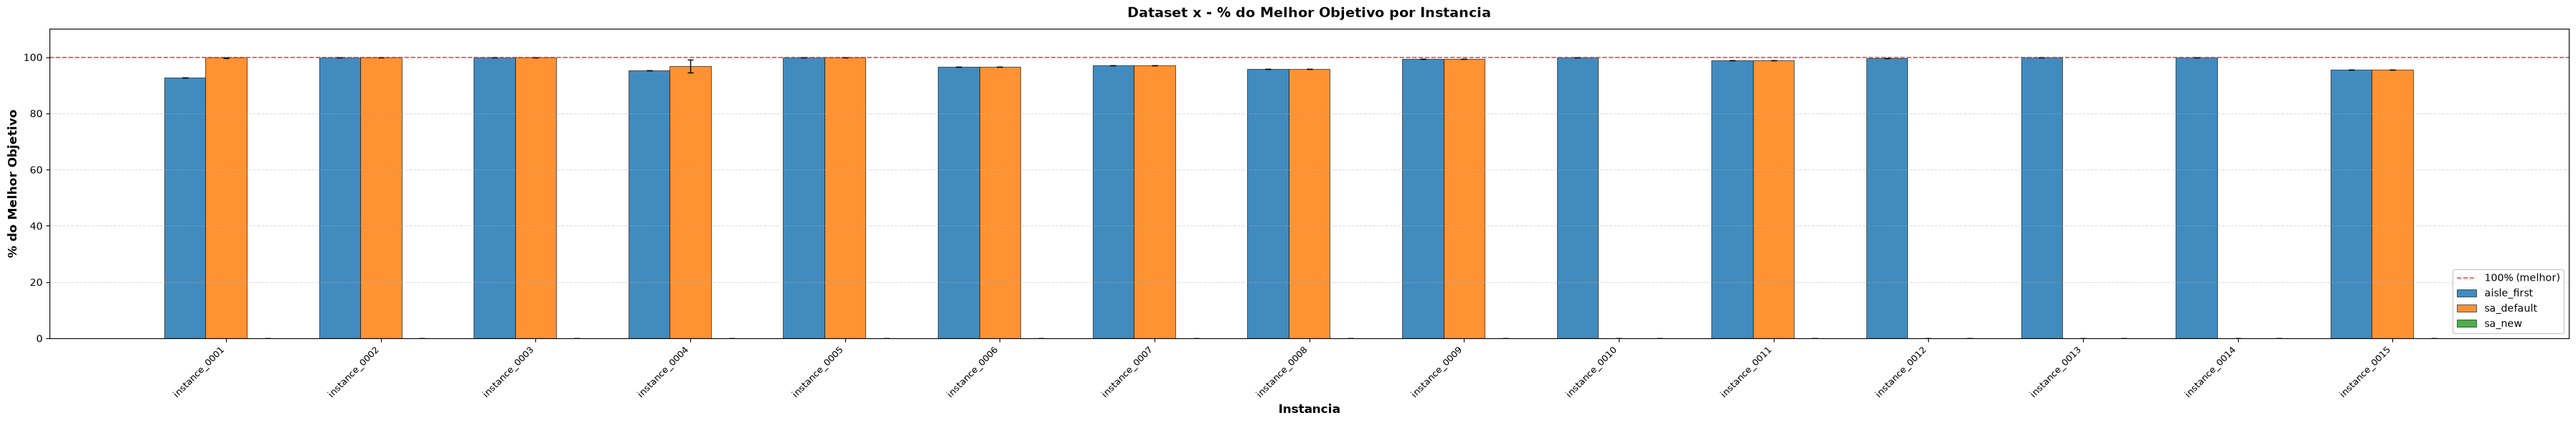

In [42]:
# --- Grafico de barras: % do melhor objetivo por instancia, por dataset ---
import matplotlib.pyplot as plt
import numpy as np

if df_ok.empty or 'pct_best' not in df_ok.columns:
    print('[INFO] Nenhum dado disponivel para gerar o grafico de barras.')
else:
    df_valido = df_ok.dropna(subset=['pct_best']).copy()
    datasets = sorted(df_valido['dataset'].unique())
    algos = sorted(df_valido['algo_id'].unique())
    n_algos = len(algos)

    # Paleta de cores para os algoritmos
    COLORS = plt.cm.tab10.colors
    algo_color = {algo: COLORS[i % len(COLORS)] for i, algo in enumerate(algos)}

    for ds in datasets:
        df_ds = df_valido[df_valido['dataset'] == ds]
        instancias = sorted(df_raw[df_raw['dataset'] == ds]['instance'].unique())
        n_inst = len(instancias)

        fig, ax = plt.subplots(figsize=(max(10, n_inst * 0.8 * n_algos), 6))

        x = np.arange(n_inst)
        width = 0.8 / n_algos if n_algos > 0 else 0.8
        offsets = np.linspace(-(n_algos - 1) / 2, (n_algos - 1) / 2, n_algos) * width

        for i, algo in enumerate(algos):
            medias = []
            erros = []
            for inst in instancias:
                sub = df_ds[(df_ds['algo_id'] == algo) & (df_ds['instance'] == inst)]['pct_best']
                if len(sub) > 0:
                    medias.append(sub.mean())
                    erros.append(sub.std() if len(sub) > 1 else 0.0)
                else:
                    medias.append(0.0)
                    erros.append(0.0)

            ax.bar(
                x + offsets[i],
                medias,
                width=width,
                yerr=erros,
                label=algo,
                color=algo_color[algo],
                alpha=0.85,
                capsize=3,
                edgecolor='black',
                linewidth=0.5,
                error_kw={'elinewidth': 1, 'capthick': 1}
            )

        ax.set_xticks(x)
        ax.set_xticklabels(instancias, rotation=45, ha='right', fontsize=9)
        ax.set_xlabel('Instancia', fontsize=12, fontweight='bold')
        ax.set_ylabel('% do Melhor Objetivo', fontsize=12, fontweight='bold')
        ax.set_title(f'Dataset {ds} - % do Melhor Objetivo por Instancia', fontsize=14, fontweight='bold', pad=12)
        ax.axhline(y=100, color='red', linestyle='--', linewidth=1.2, alpha=0.7, label='100% (melhor)')
        ax.set_ylim(0, max(110, ax.get_ylim()[1]))
        ax.legend(loc='lower right', fontsize=10, framealpha=0.95)
        ax.grid(True, axis='y', linestyle='--', alpha=0.4)

        plt.tight_layout()
        path_png = OUTPUT_DIR / f'barplot_dataset_{ds}.png'
        fig.savefig(path_png, dpi=150, bbox_inches='tight')
        print(f'Grafico salvo em: {path_png}')
        plt.show()


In [43]:
filtered = df_valido[
    (df_valido['dataset'] == 'a') &
    (df_valido['algo_id'] == 'sa_default') 
    # (df_valido['instance'] == 'instance_0009')
]
filtered

,algo_id,run_id,status,objective,items,aisles,exec_time,dataset,instance,result_dir,best_objective,pct_best
250,sa_default,2,feasible,15.000000,30,2,8.969,a,instance_0001,result_0009,15.000000,100.000000
251,sa_default,1,feasible,15.000000,30,2,9.804,a,instance_0001,result_0009,15.000000,100.000000
252,sa_default,2,feasible,2.000000,2,1,2.839,a,instance_0002,result_0009,2.000000,100.000000
253,sa_default,1,feasible,2.000000,2,1,2.821,a,instance_0002,result_0009,2.000000,100.000000
254,sa_default,1,feasible,10.500000,84,8,18.626,a,instance_0003,result_0009,12.000000,87.500000
255,sa_default,2,feasible,12.000000,48,4,19.122,a,instance_0003,result_0009,12.000000,100.000000
256,sa_default,2,feasible,3.500000,7,2,4.639,a,instance_0004,result_0009,3.500000,100.000000
257,sa_default,1,feasible,3.500000,7,2,4.683,a,instance_0004,result_0009,3.500000,100.000000
258,sa_default,2,feasible,172.375000,1379,8,600.890,a,instance_0005,result_0009,177.875000,96.907941
259,sa_default,1,feasible,172.375000,1379,8,601.164,a,instance_0005,result_0009,177.875000,96.907941
